In [28]:
#export_file = 'project-1-at-2026-01-21-12-30-8a4a6a83.json'

export_file = "annotations.json"

import requests
import json

# Configuration
LABEL_STUDIO_URL = "http://192.168.4.35:8080"
API_KEY = "***REMOVED***"
PROJECT_ID = 1  # your project ID

# Export annotations
response = requests.get(
    f"{LABEL_STUDIO_URL}/api/projects/{PROJECT_ID}/export",
    headers={"Authorization": f"Token {API_KEY}"},
    params={"exportType": "JSON"}
)

annotations = response.json()

# Save to file
with open(export_file, "w") as f:
    json.dump(annotations, f, indent=2)

print(f"Downloaded {len(annotations)} bytes")

Downloaded 505 bytes


In [29]:
import json
from pathlib import Path
import os

with open(export_file) as f:
    data = json.load(f)

print(f"Total annotations: {len(data)}")

sample = data[0]
image_path = sample['data']['image']
print(f"Example: {image_path} Exist:{os.path.exists(image_path)}")

Total annotations: 505
Example: /data/upload/1/8faa16c6-Ziffer_0_0001.jpg Exist:True


In [30]:
import shutil

dataset_dir = Path('dataset')

# Purge existing data
if dataset_dir.exists():
    shutil.rmtree(dataset_dir)

dataset_dir.mkdir(exist_ok=True)

for item in data:
    # Label extrahieren
    annotations = item.get('annotations', [])
    if not annotations:
        continue
    
    result = annotations[0]['result']
    if not result:
        continue
    
    label = result[0]['value']['choices'][0]
    
    # Klassen-Ordner
    class_dir = dataset_dir / label
    class_dir.mkdir(exist_ok=True)
    
    # Bild-Pfad extrahieren und anpassen
    img_path = item['data']['image']
    # Falls Pfad Format: /data/local-files/?d=images/file.jpg
    if '?d=' in img_path:
        img_path = img_path.split('?d=')[1]
        img_path = os.path.join("/import", img_path)
    
    src_file = Path(img_path)
    if src_file.exists():
        shutil.copy(src_file, class_dir / src_file.name)
        #print(f"✓ {label}/{src_file.name}")
    else:
        print(f"✗ Not found: {img_path}")

print(f"\nDataset structure created in: {dataset_dir}")


Dataset structure created in: dataset


In [31]:
import random
from pathlib import Path
import shutil

# NAN samples auf ~30 reduzieren
nan_dir = Path('dataset/NAN')
nan_images = list(nan_dir.glob('*'))

current_count = len(nan_images)
target_count = 30

if current_count > target_count:
    to_remove = random.sample(nan_images, current_count - target_count)
    for img in to_remove:
        img.unlink()
    print(f"NAN reduced from {current_count} to {len(list(nan_dir.glob('*')))} images")
else:
    print(f"NAN already has {current_count} images (target: {target_count})")

NAN reduced from 124 to 30 images


In [32]:
from collections import Counter

classes = [d.name for d in dataset_dir.iterdir() if d.is_dir()]
counts = {cls: len(list((dataset_dir/cls).glob('*'))) for cls in classes}

print("Dataset distribution:")
for cls, count in counts.items():
    print(f"  {cls}: {count} images")

Dataset distribution:
  5: 19 images
  9: 20 images
  2: 19 images
  1: 30 images
  7: 22 images
  6: 27 images
  8: 34 images
  NAN: 30 images
  4: 19 images
  3: 81 images
  0: 108 images


from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch.utils.data import DataLoader, random_split
import torch

resolution = 144

# Transformationen
transform = transforms.Compose([
    transforms.Resize((resolution, resolution)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Dataset laden
dataset = ImageFolder('dataset', transform=transform)

# Train/Val Split
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_ds, val_ds = random_split(dataset, [train_size, val_size])

# DataLoader
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=16, num_workers=2)

print(f"Classes: {dataset.classes}")
print(f"Train samples: {train_size}")
print(f"Val samples: {val_size}")

In [33]:
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch.utils.data import DataLoader, Subset
import torch
import random

resolution = 144

# Separate transforms for train/val
train_transform = transforms.Compose([
    transforms.Resize((resolution, resolution)),
    transforms.RandomRotation(degrees=5),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((resolution, resolution)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Load dataset and create stratified split manually
dataset_temp = ImageFolder('dataset')
indices_by_class = {}
for idx, (_, label) in enumerate(dataset_temp):
    if label not in indices_by_class:
        indices_by_class[label] = []
    indices_by_class[label].append(idx)

train_idx = []
val_idx = []
random.seed(42)
for label, indices in indices_by_class.items():
    random.shuffle(indices)
    split_point = int(0.8 * len(indices))
    train_idx.extend(indices[:split_point])
    val_idx.extend(indices[split_point:])

# Create datasets with appropriate transforms
train_dataset = ImageFolder('dataset', transform=train_transform)
train_ds = Subset(train_dataset, train_idx)

val_dataset = ImageFolder('dataset', transform=val_transform)
val_ds = Subset(val_dataset, val_idx)

# DataLoader
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=16, num_workers=2)

print(f"Classes: {dataset_temp.classes}")
print(f"Train samples: {len(train_ds)}")
print(f"Val samples: {len(val_ds)}")

Classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'NAN']
Train samples: 324
Val samples: 85


In [36]:
#!pip install timm
import timm

model_name = 'mobilenetv3_small_100' # 1.5M, 30s, baseline

num_classes = len(dataset.classes)
model_filename = f'model_{model_name}_c{num_classes}_r{resolution}'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# Lightweight model für Intel iGPU
model = timm.create_model('mobilenetv3_small_100', 
                          pretrained=True, 
                          num_classes=len(dataset.classes),
                          drop_rate=0.2 # added
                         )
model = model.to(device)

#optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4, weight_decay=1e-4)
criterion = torch.nn.CrossEntropyLoss()

# Also save the loss/acc data over trainings
train_losses = []
val_accs = []
total_epochs = 0

print(f"Model: {model.__class__.__name__}")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Device: cpu
Model: MobileNetV3
Parameters: 1,529,131


Epoch 1/10 - Loss: 2.8529 - Val Acc: 57.65% - Time: 5.1s
Epoch 2/10 - Loss: 1.2411 - Val Acc: 84.71% - Time: 4.4s
Epoch 3/10 - Loss: 0.8789 - Val Acc: 91.76% - Time: 4.2s
Epoch 4/10 - Loss: 0.4473 - Val Acc: 97.65% - Time: 4.4s
Epoch 5/10 - Loss: 0.3035 - Val Acc: 98.82% - Time: 4.3s
Epoch 6/10 - Loss: 0.1985 - Val Acc: 100.00% - Time: 4.4s
Epoch 7/10 - Loss: 0.1649 - Val Acc: 98.82% - Time: 4.4s
Epoch 8/10 - Loss: 0.2503 - Val Acc: 100.00% - Time: 5.0s
Epoch 9/10 - Loss: 0.1872 - Val Acc: 100.00% - Time: 4.3s
Epoch 10/10 - Loss: 0.1472 - Val Acc: 98.82% - Time: 4.3s

Total training time: 44.8s (0.7min)


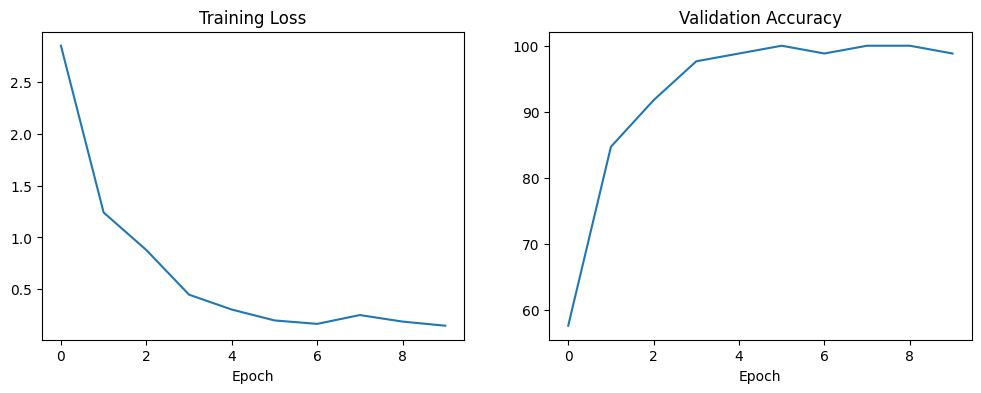

Best model from epoch 10 with 0.147 loss


In [37]:
import matplotlib.pyplot as plt
import time

epochs = 10

total_start = time.time()

best_val_loss = 1
best_epoch = 0
best_model_state = None

for epoch in range(epochs):
    epoch_start = time.time()

    # Training
    model.train()
    epoch_loss = 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
    
    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    
    # Validation
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    val_acc = 100 * correct / total
    val_accs.append(val_acc)

    if avg_loss < best_val_loss:
        best_val_loss = avg_loss
        best_epoch = epoch
        best_model_state = model.state_dict().copy()


    epoch_time = time.time() - epoch_start
    
    print(f"Epoch {total_epochs+epoch+1}/{epochs+total_epochs} - Loss: {avg_loss:.4f} - Val Acc: {val_acc:.2f}% - Time: {epoch_time:.1f}s")

total_time = time.time() - total_start
print(f"\nTotal training time: {total_time:.1f}s ({total_time/60:.1f}min)")
total_epochs += epochs

# Plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(train_losses)
ax1.set_title('Training Loss')
ax1.set_xlabel('Epoch')
ax2.plot(val_accs)
ax2.set_title('Validation Accuracy')
ax2.set_xlabel('Epoch')
plt.show()

model.load_state_dict(best_model_state)
print(f"Best model from epoch {best_epoch+1} with {best_val_loss:.3f} loss")

In [38]:
model.cpu()
model.eval()

dummy_input = torch.randn(1, 3, resolution, resolution)

# Legacy Export ohne dynamo
torch.onnx.export(
    model,
    dummy_input,
    f'{model_filename}.onnx',
    export_params=True,
    opset_version=11,
    input_names=['input'],
    output_names=['output']
)

print(f"✓ ONNX model saved: {model_filename}.onnx")


/tmp/ipykernel_8545/727429113.py:7: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter will be the default. To switch now, set dynamo=True in torch.onnx.export. This new exporter supports features like exporting LLMs with DynamicCache. We encourage you to try it and share feedback to help improve the experience. Learn more about the new export logic: https://pytorch.org/docs/stable/onnx_dynamo.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html.
  torch.onnx.export(


✓ ONNX model saved: model_mobilenetv3_small_100_c11_r144.onnx


In [39]:
import openvino as ov

# ONNX zu OpenVINO konvertieren
core = ov.Core()
model_onnx = core.read_model(f'{model_filename}.onnx')

# Kompilieren und serialisieren
ov.save_model(model_onnx, f'ov_model/{model_filename}.xml')

print(f"✓ OpenVINO model saved: ov_model/{model_filename}.xml")


✓ OpenVINO model saved: ov_model/model_mobilenetv3_small_100_c11_r144.xml


In [40]:
import openvino as ov
import cv2
import numpy as np

core = ov.Core()
print(f"Available devices: {core.available_devices}")

# Model laden + kompilieren
model_import = core.read_model(f'ov_model/{model_filename}.xml')
compiled = core.compile_model(model_import, 'GPU')

# Test Image
test_img_path = list(Path('dataset').rglob('*.jpg'))[0]
img = cv2.imread(str(test_img_path))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (resolution, resolution))

# Preprocessing
img_normalized = img.astype(np.float32) / 255.0
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img_normalized = (img_normalized - mean) / std
img_input = img_normalized.transpose(2, 0, 1)[np.newaxis, ...]

# Inference
result = compiled([img_input])[compiled.output(0)]

# Softmax für 0-1 Probabilities
result_softmax = np.exp(result[0]) / np.exp(result[0]).sum()
predicted_idx = result_softmax.argmax()
confidence = result_softmax[predicted_idx]

print(f"Test image: {test_img_path.name}")
print(f"Predicted class: {dataset.classes[predicted_idx]}")
print(f"Confidence: {confidence:.1%}")  # z.B. 98.5%


Available devices: ['CPU', 'GPU']
Test image: 7d48464c-ziffer5_2019-11-10_08-51-30.jpg
Predicted class: 5
Confidence: 99.9%
